**Student Name:** Prachi Pandey

**Project Title:** Retail Store Sales Dashboard

**Section-01** :- **Project Information**

# Retail Store Sales Dashboard

**Objective** : The objective of this project is to analyze retail store sales data, identify sales trends, evaluate product performance, and generate business insights using data visualization and statistical analysis.

## Tools and Technologies Used

- Python
- Google Colab
- Pandas
- NumPy
- Matplotlib
- Seaborn

In [2]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

**Section-02** :- **Data Loading and Initial Exploration**

In [3]:
# Load the dataset
df = pd.read_csv("SalesAnalysisdataset.csv")

# Display first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [5]:
# Check number of rows and columns
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(10194, 21)


In [6]:
# Display all column names
print("Column Names:")
print(df.columns)

Column Names:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')


In this section, the dataset is loaded into the notebook and basic information such as rows, columns, and dataset structure is examined.

**Section-03** :- **Dataset Understanding**

In [7]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

In [8]:
# Display statistical summary of numerical columns
df.describe()

,Row ID,Sales,Quantity,Discount,Profit
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,228.225854,3.791838,0.155385,28.673417
std,2942.898656,619.906839,2.228317,0.206249,232.465115
min,1.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,209.500000,5.000000,0.200000,29.297925
max,10194.000000,22638.480000,14.000000,0.800000,8399.976000


In [9]:
# Check missing values in each column
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country/Region,0
City,0


In [10]:
# Check duplicate records
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In this section, the structure of the dataset is examined. Data types, missing values, duplicate records, and statistical summaries are analyzed to understand the quality of the data before preprocessing.

**Section-04** :- **Data Preprocessing**

In [11]:
# Convert date columns into datetime format
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Create Month and Year columns from Order Date
df["Order Month"] = df["Order Date"].dt.month_name()
df["Order Year"] = df["Order Date"].dt.year

# Display first few rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Month,Order Year
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,January,2023
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,January,2023
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717,January,2023
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748,January,2023
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840,January,2023


In [12]:
# Check updated data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  object        
 2   Order Date      10194 non-null  datetime64[ns]
 3   Ship Date       10194 non-null  datetime64[ns]
 4   Ship Mode       10194 non-null  object        
 5   Customer ID     10194 non-null  object        
 6   Customer Name   10194 non-null  object        
 7   Segment         10194 non-null  object        
 8   Country/Region  10194 non-null  object        
 9   City            10194 non-null  object        
 10  State/Province  10194 non-null  object        
 11  Postal Code     10194 non-null  object        
 12  Region          10194 non-null  object        
 13  Product ID      10194 non-null  object        
 14  Category        10194 non-null  object        
 15  Su

**Section-05** :- **Overall Business Performance**

Overall Business Performance : The following metrics provide an overview of the retail store's performance including total sales, total profit, and total number of orders.

In [13]:
# Calculate basic business statistics

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()

print("Total Sales :", round(total_sales, 2))
print("Total Profit :", round(total_profit, 2))
print("Total Orders :", total_orders)

Total Sales : 2326534.35
Total Profit : 292296.81
Total Orders : 5111


In this section, date columns are converted into datetime format. Additional features such as Order Month and Order Year are created to support sales trend analysis.

**Section-06** :- **Data Visualization**

## Category Wise Sales Analysis

This visualization shows the total sales generated by each product category. It helps identify the best-performing categories in the retail store.

Category
Furniture          754747.7613
Office Supplies    731893.3140
Technology         839893.2790
Name: Sales, dtype: float64


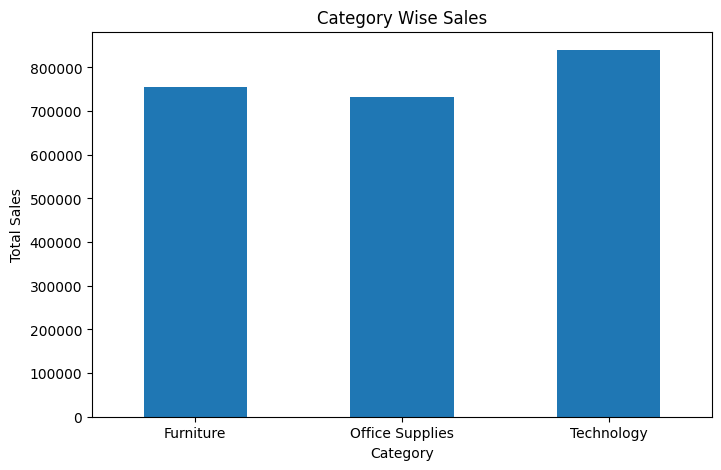

In [19]:
# Calculate category-wise sales
category_sales = df.groupby("Category")["Sales"].sum()

# Display category sales
print(category_sales)

# Create bar chart
plt.figure(figsize=(8,5))

category_sales.plot(
    kind="bar"
)

plt.title("Category Wise Sales")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.show()

## Category Wise Profit Analysis

This chart displays the profit generated by each product category and helps determine which categories contribute most to business profitability.

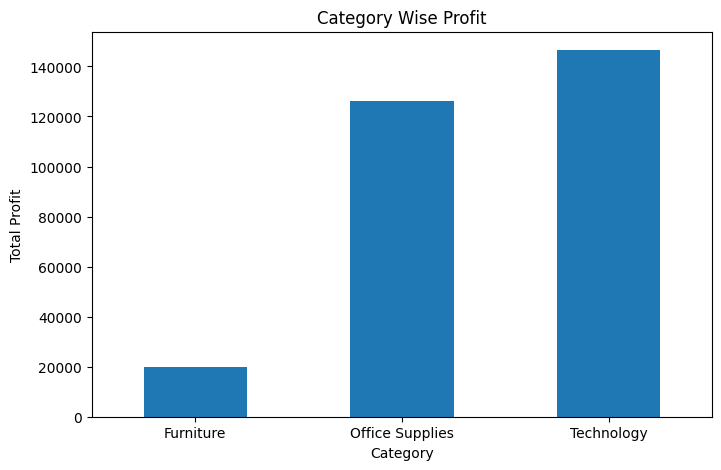

In [20]:
# Calculate category-wise profit
category_profit = df.groupby("Category")["Profit"].sum()

# Create bar chart
plt.figure(figsize=(8,5))

category_profit.plot(
    kind="bar"
)

plt.title("Category Wise Profit")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.xticks(rotation=0)

plt.show()

In [21]:
# Identify best-selling category

best_category = category_sales.idxmax()
best_sales = category_sales.max()

print("Best Selling Category :", best_category)
print("Sales :", round(best_sales, 2))

Best Selling Category : Technology
Sales : 839893.28


**Observation**: Technology category generated the highest sales revenue of 839,893.28, making it the best-performing category. Furniture and Office Supplies contributed lower sales compared to Technology.

## Monthly Revenue Trend Analysis

This analysis examines monthly sales trends to identify peak sales periods and understand business growth patterns over time.

Order Month
April        138098.7486
August       161821.9150
December     330218.1755
February      59751.2514
January       96069.5156
July         149001.7130
June         153459.9973
March        210672.0868
May          158765.0337
November     352665.9910
October      207126.2567
September    308883.6697
Name: Sales, dtype: float64


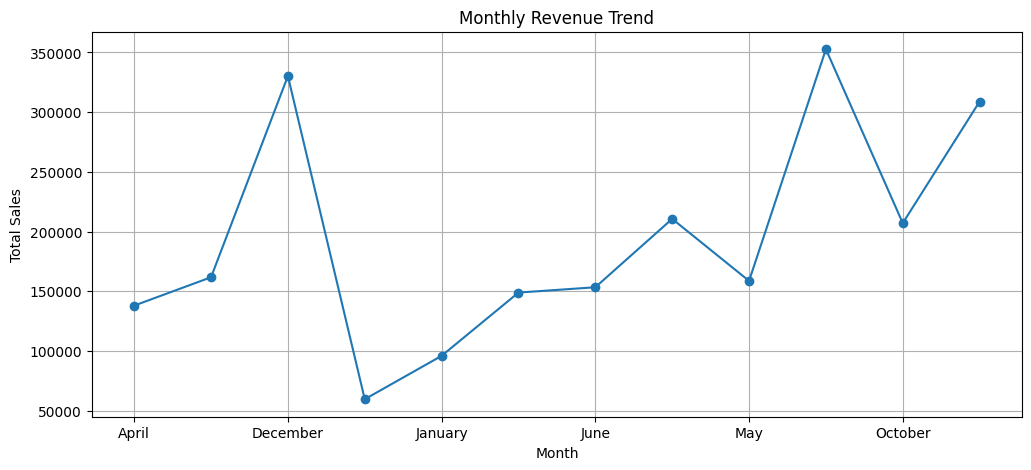

In [22]:
# Calculate monthly sales revenue
monthly_sales = df.groupby("Order Month")["Sales"].sum()

# Display monthly sales
print(monthly_sales)

# Create line chart
plt.figure(figsize=(12,5))

monthly_sales.plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.grid(True)

plt.show()

## Monthly Revenue Trend (Chronological Order)

This visualization presents monthly sales revenue in chronological order, allowing better analysis of seasonal sales patterns and revenue growth.

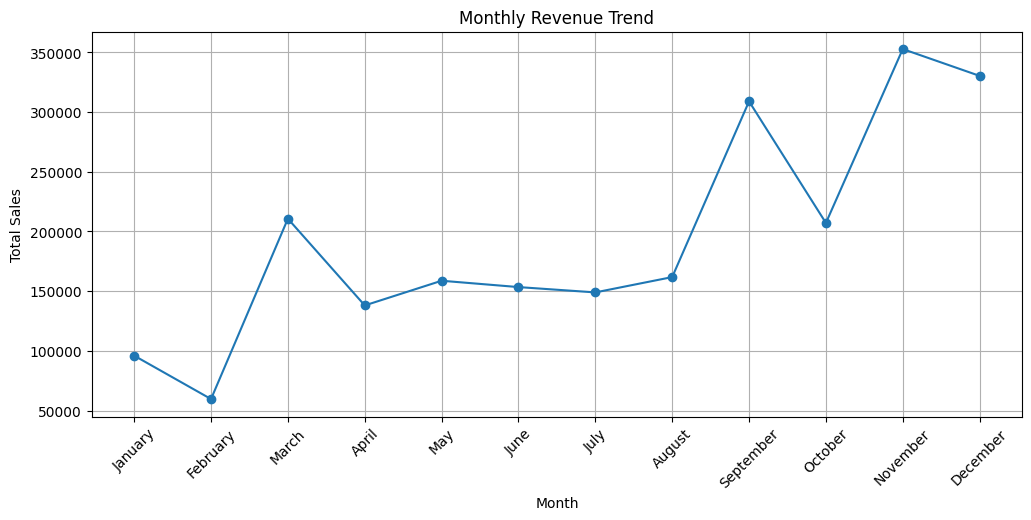

In [23]:
# Define correct month order
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

# Calculate monthly sales and reorder months
monthly_sales = df.groupby("Order Month")["Sales"].sum()
monthly_sales = monthly_sales.reindex(month_order)

# Create line chart
plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

**Observation**: Monthly sales revenue fluctuated throughout the year. Certain months recorded significantly higher sales, indicating seasonal demand patterns and peak business periods.

## Top 10 Best Selling Products

This analysis identifies the products that generated the highest sales revenue for the retail store.

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


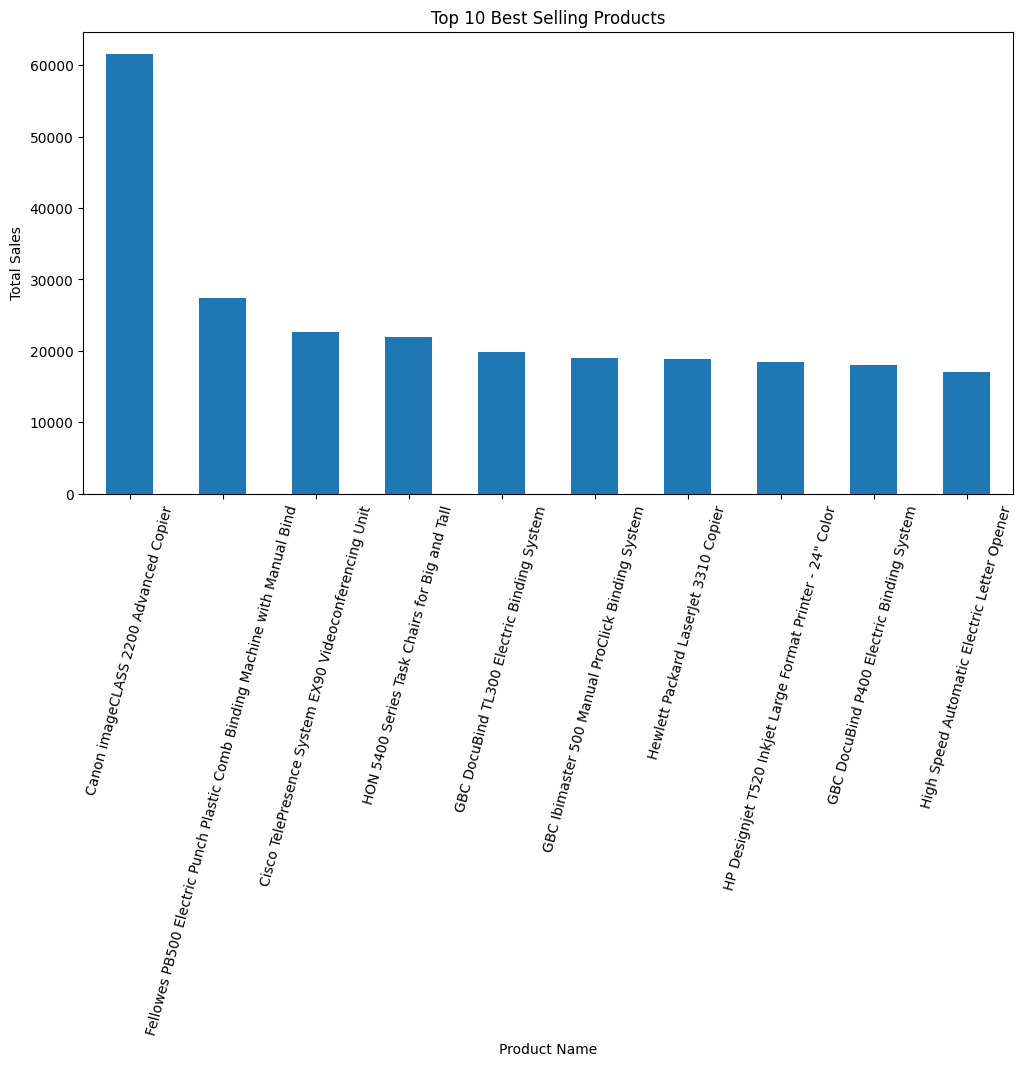

In [24]:
# Top 10 products based on sales
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

# Create bar chart
plt.figure(figsize=(12,6))

top_products.plot(kind="bar")

plt.title("Top 10 Best Selling Products")
plt.xlabel("Product Name")
plt.ylabel("Total Sales")

plt.xticks(rotation=75)

plt.show()

**Observation**: The chart highlights the top-performing products based on sales revenue. These products contribute significantly to overall business performance and customer demand.

## Region Wise Sales Analysis

This analysis shows the sales performance across different regions and helps identify the regions contributing most to overall revenue.

Region
West       739813.6085
East       691828.1680
Central    503170.6728
South      391721.9050
Name: Sales, dtype: float64


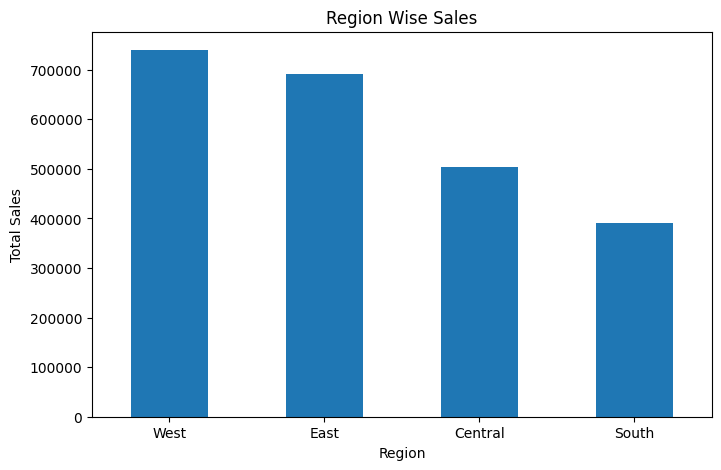

In [25]:
# Calculate region-wise sales
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

# Display sales by region
print(region_sales)

# Create bar chart
plt.figure(figsize=(8,5))

region_sales.plot(kind="bar")

plt.title("Region Wise Sales")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.show()

**Observation**: The region with the highest sales contributes significantly to overall business revenue, while other regions show comparatively lower sales performance.

## Customer Segment Analysis

This analysis evaluates sales generated from different customer segments and helps understand customer buying behavior.

Segment
Consumer       1.170660e+06
Corporate      7.158061e+05
Home Office    4.400684e+05
Name: Sales, dtype: float64


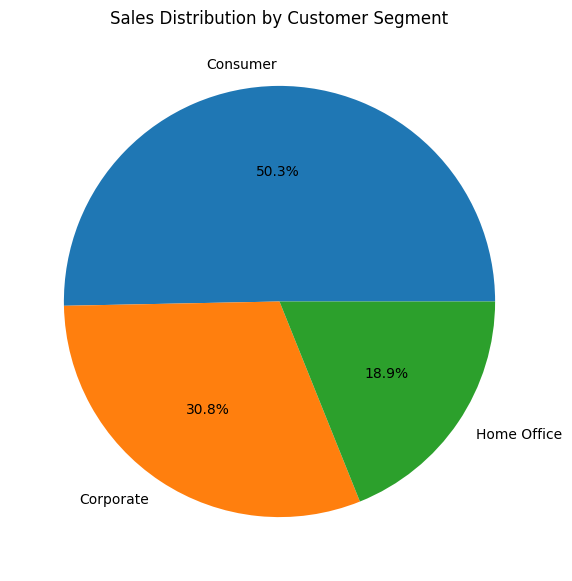

In [26]:
# Calculate segment-wise sales
segment_sales = df.groupby("Segment")["Sales"].sum()

# Display segment sales
print(segment_sales)

# Create pie chart
plt.figure(figsize=(7,7))

plt.pie(
    segment_sales,
    labels=segment_sales.index,
    autopct="%1.1f%%"
)

plt.title("Sales Distribution by Customer Segment")

plt.show()

**Observation**: The customer segment contributing the highest percentage of sales represents the most valuable customer group for the business.

## Profit vs Discount Analysis

This visualization examines the relationship between discounts and profit to understand how discount strategies affect business profitability.

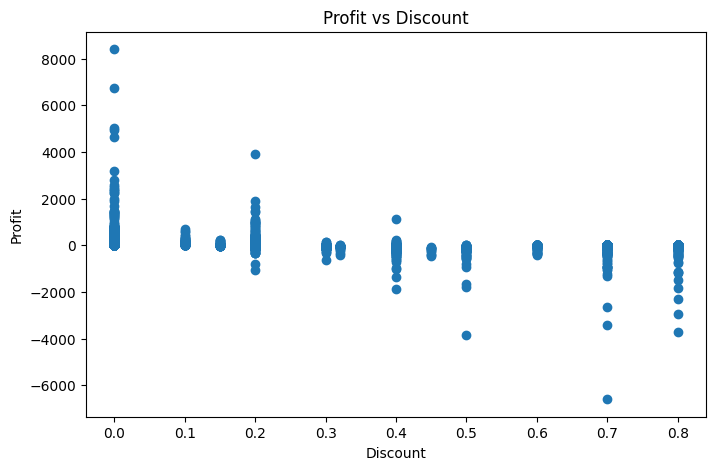

In [27]:
# Scatter plot between discount and profit

plt.figure(figsize=(8,5))

plt.scatter(
    df["Discount"],
    df["Profit"]
)

plt.title("Profit vs Discount")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

**Observation**: Higher discounts often reduce profitability. The scatter plot helps identify whether excessive discounts negatively impact profits.

## Top 10 States by Sales

This analysis identifies the states generating the highest sales revenue for the retail store.

State/Province
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64


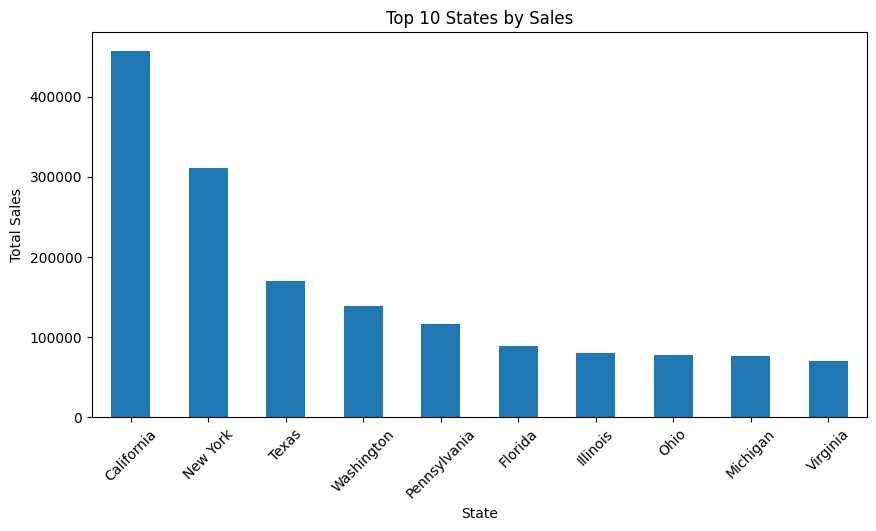

In [28]:
# Top 10 states by sales
top_states = (
    df.groupby("State/Province")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_states)

# Create bar chart
plt.figure(figsize=(10,5))

top_states.plot(kind="bar")

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

**Section-07** :- **Key Insights**

1. Technology category generated the highest sales revenue among all product categories.

2. The retail store achieved total sales of 2.33 million and total profit of 292 thousand.

3. Monthly sales revenue showed significant fluctuations throughout the year, indicating seasonal sales patterns.

4. Sales increased considerably during the final months of the year, especially in November and December.

5. Certain products contributed significantly more revenue than others, highlighting key revenue-generating products.

6. Customer segments showed different purchasing behaviors and revenue contributions.

7. Regional analysis revealed that some regions generated substantially higher sales than others.

8. Discounts had a noticeable impact on profitability and should be managed carefully.

9. A small number of products contributed a large portion of overall sales revenue.

10. Data analysis helped identify business trends, customer behavior, and opportunities for improving profitability.

**Section-08** :- **Conclusion**

This project analyzed retail store sales data using Python, Pandas, NumPy, Matplotlib, and Seaborn.

The dataset was cleaned, explored, and visualized to understand sales performance, product trends, customer behavior, and profitability.

The analysis revealed that the Technology category was the highest revenue-generating category. Monthly sales trends showed seasonal variations, while customer segment and regional analyses provided valuable business insights.

Overall, this project demonstrates how data analytics can be used to transform raw business data into meaningful information that supports better decision-making and business growth.

# Thank You

This project was successfully completed using Google Colab and Python Data Analysis Libraries.